### Disclaimer : we'll only work with the onset state as target (s=1), and set the s=2 as 0


In [2]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay as plot_cm
import matplotlib.pyplot as plt
import datetime as dt
import sys
from scipy.signal import medfilt
from pathlib import Path
sys.path.append(f"{Path.home()}/pavnet-v3/vlfcode/")
#sys.path.append("/home/aldo/maestria/tesis/vlf/code/")
from sxrf_download import sunpy_xrf
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
#xr_df = sunpy_xrf("2025-01-1 12:00", "2025-08-26 21:59", sat_number=18)
import hmmlearn
import modelutils as mu 
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression as mar



In [3]:


# df = pd.read_csv(...) 
df1 = pd.read_csv("vlf_trainingdata_2025_piu.csv", index_col=[0],parse_dates=[0])
df2 = pd.read_csv("vlf_test_2026_piu.csv", index_col=[0],parse_dates=[0])
#df2.rename(columns={"GOES-18_long": "GOES18"}, inplace=True)
df2.drop(columns=["GOES-18_long"], inplace=True)
#df2.columns = [ "NAA","GOES18" ,"state" ,"GOES19", "flare_class"]
_df2 = df2[ ["NAA","GOES18" ,"state" ,"GOES19"]]
_df1 = df1[ ["NAA","GOES18" ,"state" ,"GOES19"]]
#df = df1.join(df2[[ "NAA","GOES18" ,"GOES18" ,"state" ,"GOES19"]], how="left")
# Drop duplicate rows within each DataFrame (keep first occurrence per timestamp)
_df1 = _df1[~_df1.index.duplicated(keep='first')]
_df2 = _df2[~_df2.index.duplicated(keep='first')]

# Now concatenate and drop duplicates across the combined set
combined = pd.concat([_df1, _df2])
df = combined[~combined.index.duplicated(keep='first')]  # or keep='last'
# set state decay (2) as normal (0)
df.loc[df["state"]==2, "state"] = 0

In [3]:
df.columns

Index(['NAA', 'GOES18', 'state', 'GOES19'], dtype='str')

In [4]:
lowp = signal.firwin(101, 0.01, fs=1/10)
df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
#df['NAA_dB'] = 20 * np.log10(df['NAA-filt'] + 1e-9)
# derivada o velocidad de cambio

df.head()

df.loc[:, 'NAA'] = df['NAA'].clip(lower=-10)
background = df['NAA'].rolling(window=60, center=False).min()
df["NAA_dB_bgrm"] = df["NAA"]-background #brackground removed
df['Delta'] = df['NAA'].diff(5).fillna(0)

In [5]:
df2.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'flare_class'], dtype='str')

In [6]:

df["time"] = df.index.time
df["date"] = df.index.date
pivotdf = df.pivot(values="NAA", columns="time", index="date")#.dropna()
pivot_qdc = pivotdf.rolling(window=27, center=False, min_periods=2).median()
# removing the QDC  mask
qdc_refcurve = pivot_qdc.unstack().swaplevel().sort_index()
qdc_refcurve.index = [dt.datetime.combine(qdc_refcurve.index[i][0], qdc_refcurve.index[i][1]) for i in range(len(qdc_refcurve))]
df["qdc_ref"] = qdc_refcurve
# Actualizacion: cambio de X, X= [delta(background removed) , diff(periods=5)]
df["delta_amp"] = df["NAA"] - df["qdc_ref"]
df['diff_amp'] = df['delta_amp'].diff(5).fillna(0)




In [7]:
amp = df["delta_amp"]

# Multi-scale slopes
# df["slope_1m"]  = amp.diff(6)          # 1 min
df["slope_5m"]  = amp.diff(5)         # 5 min
df["slope_10m"] = amp.diff(10)         # 15 min

# Local "transient" feature: how far is the current sample from its 30-min median
df["transient"] = amp - amp.rolling(180, center=False, min_periods=60).median()

# Rolling volatility (onsets increase high-frequency power)
df["rv_5m"] = amp.rolling(30).std()

In [8]:
from scipy.signal import butter, filtfilt
b, a = butter(4, [1/(30), 1/(3)], btype='band', fs=1/1)  # 3–30 min band
df["bp_energy"] = filtfilt(b, a, df["delta_amp"].fillna(0))**2

In [9]:
f = lambda x:x+2
f(8)

10

In [10]:

# %matplotlib qt

In [11]:
# get transient
f_transient = lambda amp: amp - amp.rolling(180, center=False, min_periods=60).median() 

# local background
# 60 min
win         = "60min"
min_periods = 20
df["bg_local_60min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_60min"] = df["bg_local_60min"].fillna(df["qdc_ref"])
df["delta60min_amp_local"] = df["NAA"] - df["bg_local_60min"]
df["diff60min_amp_local"] = df["delta60min_amp_local"].diff(5).fillna(0)
df["transient_60"] = f_transient(df["delta60min_amp_local"])#amp - amp.rolling(180, center=False, min_periods=60).median()
# 120 min
win         = "120min"
min_periods = 20
df["bg_local_120min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_120min"] = df["bg_local_120min"].fillna(df["qdc_ref"])
df["delta120min_amp_local"] = df["NAA"] - df["bg_local_120min"]
df["diff120min_amp_local"] = df["delta120min_amp_local"].diff(5).fillna(0)

# df["transient_120"] = amp - amp.rolling(180, center=False, min_periods=60).median()
df["transient_120"] = f_transient(df["delta120min_amp_local"])

# rising score
df["rise_score"] = df["NAA"] - df["NAA"].rolling(20, min_periods=5).max()



In [12]:
# cos theta as feature
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.time import Time

loc_tx = EarthLocation(lat= 44.63678 * u.deg, lon=-67.27949 * u.deg)
loc_rx = EarthLocation(lat=-12.50423 * u.deg, lon=-76.79773 * u.deg)

def cos_theta_midpoint(index, loc_tx, loc_rx):
    '''
    cos(theta <>zenith solar) enm el putno medio del great path circle Tx-Rx
    index = DatetimeIndex
    '''
    # 3d Cartesian
    def to_xyz(lat, lon):
        lat, lon = np.deg2rad(lat), np.deg2rad(lon)
        return np.array([
            np.cos(lat)*np.cos(lon),
            np.cos(lat)*np.sin(lon),
            np.sin(lat)
        ])
    v_tx = to_xyz(loc_tx.lat.deg, loc_tx.lon.deg)
    v_rx = to_xyz(loc_rx.lat.deg, loc_rx.lon.deg)
    v_mid = v_tx + v_rx
    v_mid /= np.linalg.norm(v_mid)

    lat_mid = np.rad2deg(np.arcsin(v_mid[2]))
    lon_mid = np.rad2deg(np.arctan2(v_mid[1], v_mid[0]))
    loc_mid = EarthLocation(lat=lat_mid * u.deg, lon=lon_mid * u.deg)

    t_astro = Time(pd.DatetimeIndex(index).to_pydatetime())
    sun = get_sun(t_astro).transform_to(AltAz(obstime=t_astro, location=loc_mid))
    return np.sin(np.deg2rad(sun.alt.deg))   # cos(zenith) = sin(altitude)

df["cos_theta"] = cos_theta_midpoint(df.index, loc_tx, loc_rx)



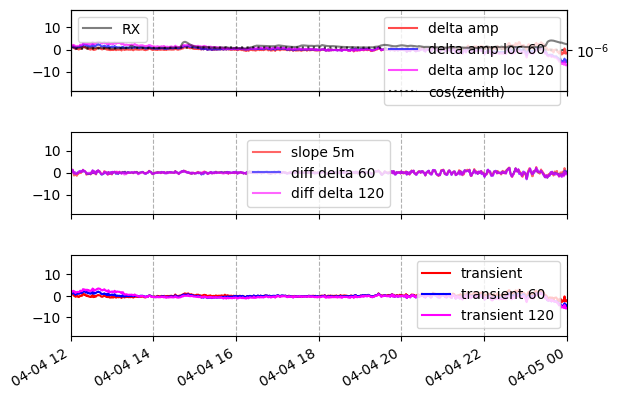

In [13]:
# plot

# %matplotlib qt
fig = plt.figure()
ax = plt.subplot(311)
ax.plot(df["delta_amp"], label="delta amp", color="red", alpha=0.7)
ax.plot(df["delta60min_amp_local"], label="delta amp loc 60", color="blue", alpha=0.7)
ax.plot(df["delta120min_amp_local"], label="delta amp loc 120", color="magenta", alpha=0.7)
ax.plot(df["cos_theta"], label="cos(zenith)", color="black",ls=":",  alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df["GOES18"], label="RX", color="k", alpha=.5)
ax2.set_yscale("log")
ax.legend(); ax2.legend()
ax.grid(axis="x", ls="--")
ax = plt.subplot(312, sharex=ax)
ax.plot(df["slope_5m"], color="red", label="slope 5m", alpha=.6)
# ax.plot(df["slope_10m"], label="slope 5m", alpha=.6)
ax.plot(df["diff60min_amp_local"],color = "blue", label="diff delta 60", alpha=.6)
ax.plot(df["diff120min_amp_local"], color="magenta", label="diff delta 120", alpha=.6)
ax.legend();
ax.grid(axis="x", ls="--")
ax = plt.subplot(313, sharex=ax)
ax.plot(df["transient"], color="r",label="transient")
ax.plot(df["transient_60"], color="blue", label="transient 60")
ax.plot(df["transient_120"], color="magenta", label="transient 120")
ax.legend()
ax.grid(axis="x", ls="--")
# ax = plt.subplot(414, sharex=ax)
# ax.plot(df["bp_energy"], label="bp_energy")
# ax.legend()
# ax.grid(axis="x", ls="--")
# ax.set_yscale("log")
ax.set_xlim(dt.datetime(2025, 4, 4,12), dt.datetime(2025, 4, 5))
fig.autofmt_xdate()
plt.subplots_adjust(hspace=0.5)
plt.show()

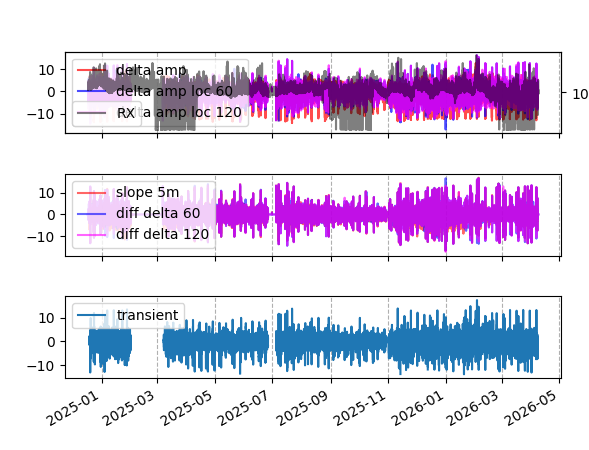

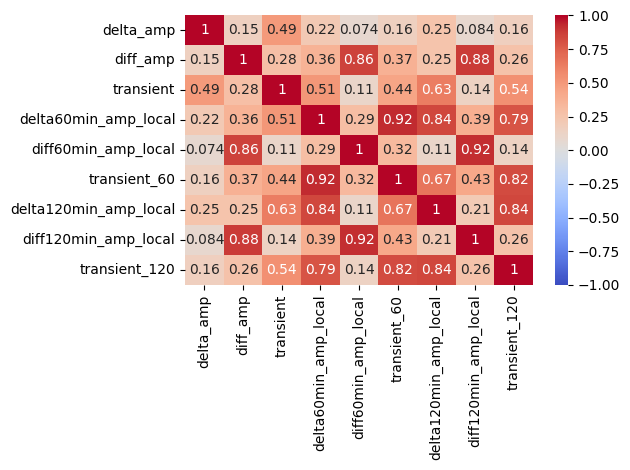

In [48]:
%matplotlib inline
import seaborn as sns
feat_names=["delta_amp", "diff_amp", "transient", "delta60min_amp_local", "diff60min_amp_local", "transient_60", 
           "delta120min_amp_local", "diff120min_amp_local", "transient_120",]

corr = pd.DataFrame(df, columns=feat_names).corr()
fig = plt.figure()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.tight_layout()

<Axes: >

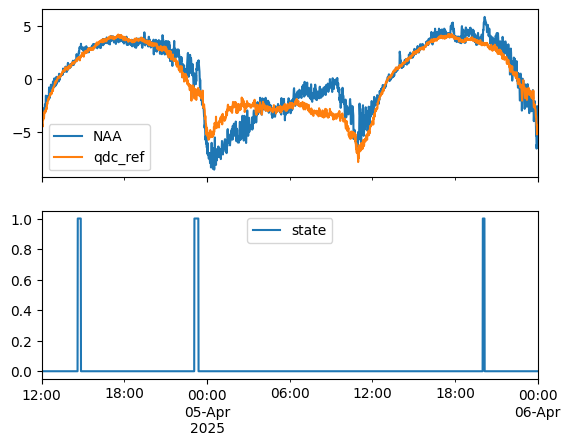

In [15]:
dl1,dl2 = dt.datetime(2025,4,4,12), dt.datetime(2025,4,6)
#df[["delta_amp","diff_amp"]].plot()
fig, axs = plt.subplots(2,1,sharex=True)
ax=axs[0]

df.loc[dl1:dl2, ["NAA","qdc_ref"]].plot(ax=ax)
# plt.xlim(dl1, dl2)
ax=axs[1]

df.loc[dl1:dl2, ["state"]].plot(ax=ax)
# plt.xlim(dl1, dl2)
#plt.axvspan(rx_suntimes[dl1.date][0], color="yellow")
#plt.axvspan(*rx_suntimes[(dl2-dt.timedelta(days=1)).date()], color="yellow")

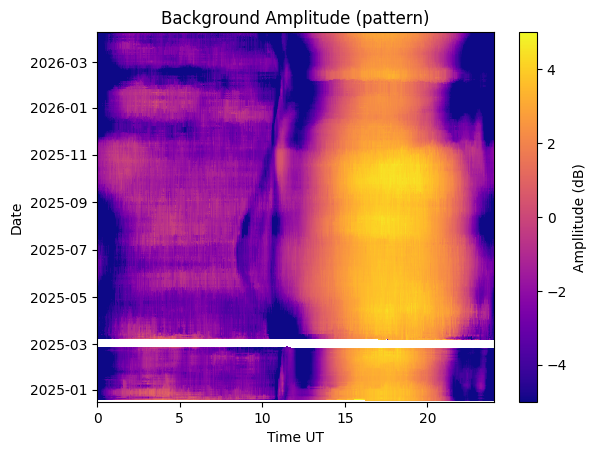

In [16]:

time_arr = np.linspace(0,24, len(pivot_qdc.columns))

fig, ax = plt.subplots()
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5,vmax=5)
ax.set_xlabel("Time UT")
ax.set_ylabel("Date")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Ampllitude (dB)")
ax.set_title("Background Amplitude (pattern)")
plt.show()



## Using ony diurnal times
based on the astronomical sunrise and sunset


In [17]:
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.time import Time

# Define observer locations
loc_tx = EarthLocation(lat=44.63678 * u.deg, lon=-67.27949 * u.deg)
loc_rx = EarthLocation(lat=-12.50423 * u.deg, lon=-76.79773 * u.deg)

# Solar elevation target angle:
#  -0.833° for standard horizon sunrise/sunset (includes atmospheric refraction)
# -18.000° for astronomical twilight (dawn/dusk)
TARGET_ALT = -0.833 


def get_sun_events(d, location, target_alt=-0.833):
    """Calculates event crossing times in UTC decimal hours using Astropy."""
    date_str = str(d)[:10]
    t0 = Time(f"{date_str} 00:00:00", scale="utc")
    times = t0 + np.linspace(0, 24, 1440) * u.hour  # 1-minute grid

    # Compute solar altitudes
    alts = (
        get_sun(times)
        .transform_to(AltAz(obstime=times, location=location))
        .alt.deg
    )
    diff = alts - target_alt

    # Detect zero-crossings
    sign_change = np.diff(np.sign(diff))
    rising_idx = np.where(sign_change > 0)[0]
    setting_idx = np.where(sign_change < 0)[0]

    return interpolate_hour(diff, rising_idx), interpolate_hour(diff, setting_idx)

def interpolate_hour(diff,idx_list):
    if len(idx_list) == 0:
        return np.nan  # Returns NaN if event doesn't occur (e.g., persistent twilight)
    i = idx_list[0]
    y0, y1 = diff[i], diff[i + 1]
    frac = -y0 / (y1 - y0)
    return (i + frac) * (24.0 / 1440.0)

# Execute loop
tx_sunrise, tx_sunset = [], []
rx_sunrise, rx_sunset = [], []
tx_suntimes = {}
rx_suntimes = {}

for d in pivot_qdc.index:
    print(f"{d}", end="\r")
    # Transmitter (TX - Maine)
    t0_tx, t1_tx = get_sun_events(d, loc_tx, target_alt=TARGET_ALT)
    tx_sunrise.append(t0_tx)
    tx_sunset.append(t1_tx)
    tx_suntimes[d] = [t0_tx, t1_tx]

    # Receiver (RX - Lima)
    t0_rx, t1_rx = get_sun_events(d, loc_rx, target_alt=TARGET_ALT)
    rx_sunrise.append(t0_rx)
    rx_sunset.append(t1_rx)
    rx_suntimes[d] = [t0_rx, t1_rx]

2026-04-08

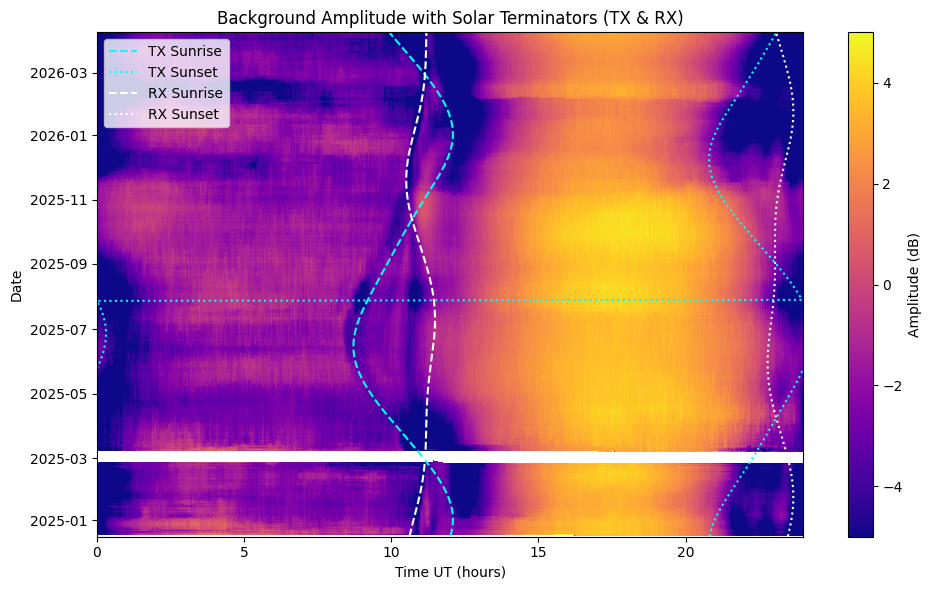

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# Mapa de calor de amplitud
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5, vmax=5)

# Curvas de Amanecer/Atardecer para TX y RX (X: hora decimal UT, Y: fechas)
ax.plot(tx_sunrise, pivot_qdc.index, color='cyan', linestyle='--', linewidth=1.5, label='TX Sunrise')
ax.plot(tx_sunset,  pivot_qdc.index, color='cyan', linestyle=':',  linewidth=1.5, label='TX Sunset')

ax.plot(rx_sunrise, pivot_qdc.index, color='white', linestyle='--', linewidth=1.5, label='RX Sunrise')
ax.plot(rx_sunset,  pivot_qdc.index, color='white', linestyle=':',  linewidth=1.5, label='RX Sunset')

# Formatos y etiquetas
ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Date")
ax.set_title("Background Amplitude with Solar Terminators (TX & RX)")
ax.set_xlim(0, 24)
ax.legend(loc='upper left', framealpha=0.8)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Amplitude (dB)")

plt.tight_layout()
plt.show()

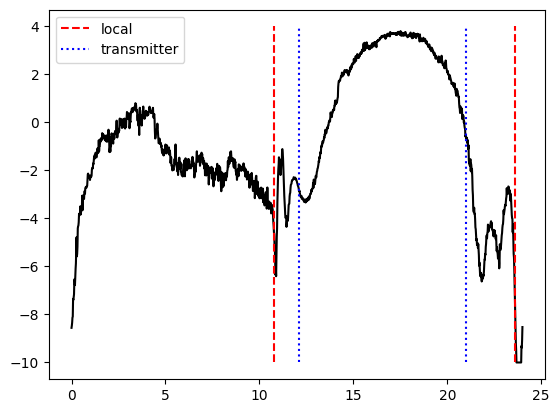

In [19]:
plt.figure()
plt.plot(time_arr, pivot_qdc.loc[dt.date(2025, 1, 1 ),:], color="k")
plt.vlines(rx_suntimes[dt.date(2025, 1, 1 )],-10,4, ls="--", color="red", label="local")
plt.vlines(tx_suntimes[dt.date(2025, 1, 1 )],-10,4, ls=":", color="blue", label="transmitter")
plt.legend()

In [20]:

# 1. Extraer fechas y convertir la hora del index a hora decimal (UT)
fechas = df.index.date
horas = df.index.hour + df.index.minute / 60.0 + df.index.second / 3600.0

# 2. Mapear t0 (sunrise) y t1 (sunset) para cada fila del DataFrame
t0_vals = np.array([max([rx_suntimes[d][0], tx_suntimes[d][0]]) if d in rx_suntimes else np.nan for d in fechas])
t1_vals = np.array([max([rx_suntimes[d][1], tx_suntimes[d][1]]) if d in rx_suntimes else np.nan for d in fechas])

# 3. MÁSCARA BOOLEANA (True = Día, False = Noche)
mask_diurna = (horas >= t0_vals) & (horas <= t1_vals)

In [21]:
df_diurno = df[mask_diurna]


In [23]:
df_diurno.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'NAA-filt', 'NAA_dB_bgrm', 'Delta',
       'time', 'date', 'qdc_ref', 'delta_amp', 'diff_amp', 'slope_5m',
       'slope_10m', 'transient', 'rv_5m', 'bp_energy', 'bg_local_60min',
       'delta60min_amp_local', 'diff60min_amp_local', 'transient_60',
       'bg_local_120min', 'delta120min_amp_local', 'diff120min_amp_local',
       'transient_120', 'rise_score', 'cos_theta'],
      dtype='str')

In [28]:
%matplotlib inline

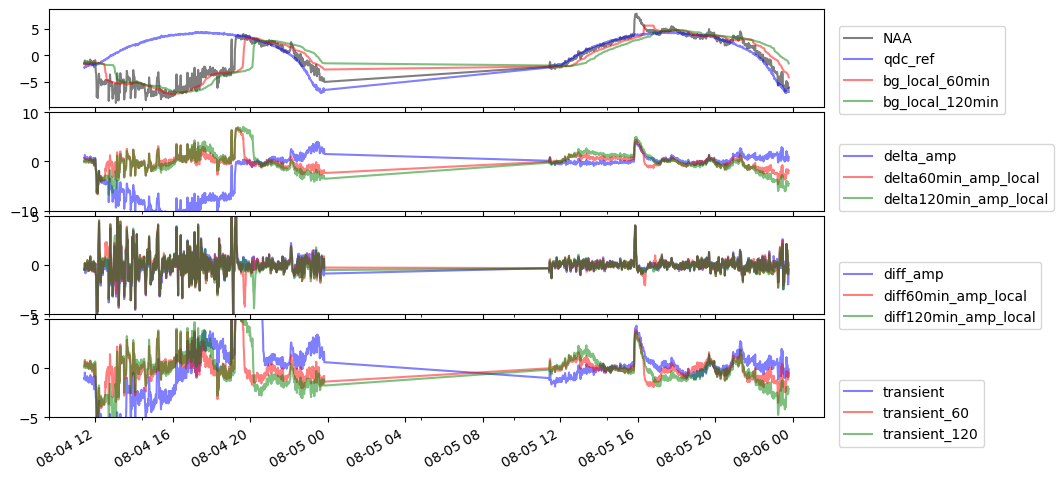

In [40]:
dl1,dl2 = dt.datetime(2025,8,4, 10), dt.datetime(2025,8,6)
#df[["delta_amp","diff_amp"]].plot()

df_ = df_diurno.loc[dl1:dl2 , ["NAA","qdc_ref", "bg_local_60min", "bg_local_120min", 
                               "delta_amp", "delta60min_amp_local", "delta120min_amp_local",
                               "diff_amp", "diff60min_amp_local", "diff120min_amp_local",
                               "transient","transient_60", "transient_120" 
                              ]
                        ]

fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(411)
df_[["NAA","qdc_ref", "bg_local_60min", "bg_local_120min"]].plot(color=[
                                                                            "black", 
                                                                            "blue", 
                                                                            "red", 
                                                                            "green"
                                                                        ], alpha=0.5,
                                                                        ax=ax
                                                                        )
ax.legend(bbox_to_anchor=(1.01, 0.9))
# df_diurno[["NAA","bg_local_60min"]].plot(color=["black", "red"], ax=ax)
#ax2 = ax.twinx()
#ax2.plot(df["GOES18"], color="purple")
#ax2.set_ylim(1e-7, 1e-3)
ax = plt.subplot(412, sharex=ax)
df_[["delta_amp", "delta60min_amp_local", "delta120min_amp_local"]].plot(color=["blue", "red", "green"], 
                                                                               ax=ax, alpha=0.5,)
ax.legend(bbox_to_anchor=(1.01, 0.75))
ax.set_ylim(-10,10)

ax = plt.subplot(413, sharex=ax)
# df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax)
df_[["diff_amp", "diff60min_amp_local", "diff120min_amp_local"]].plot(color=["blue", "red", "green"], 
                                                                            ax=ax, alpha=0.5,)
ax.legend(bbox_to_anchor=(1.01, 0.6))
ax.set_ylim(-5,5)

ax = plt.subplot(414, sharex=ax)
# df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax)
df_[["transient", "transient_60", "transient_120"]].plot(color=["blue", "red", "green"], 
                                                                            ax=ax, alpha=0.5,)
ax.legend(bbox_to_anchor=(1.01, 0.45))
ax.set_ylim(-5,5)
plt.subplots_adjust(hspace=0.05)
# plt.tight_layout()

# plt.xlim(dl1, dl2)


In [1]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k", alpha=0.5)
df_diurno[["diff_amp"]].plot(kind ="hist", color="navy", ax=ax,bins=35, edgecolor="k",alpha=0.5)

NameError: name 'plt' is not defined

9


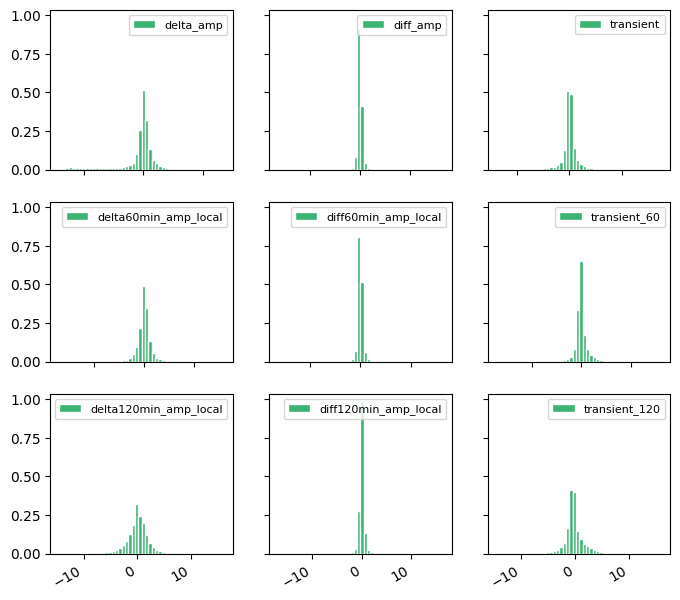

In [44]:
df_diurno.columns
features_ = ['delta_amp', 'diff_amp', 'transient', 'delta60min_amp_local', 'diff60min_amp_local', 'transient_60',
        'delta120min_amp_local', 'diff120min_amp_local', 'transient_120']
print(len(features_))
fig, axs = plt.subplots(3,3, sharey=True,figsize=(8,8))#sharex=True)

for r, rax in enumerate(axs):
    for c, ax in enumerate(rax):
        ii = 3*r+c
        f = features_[ii]
        n, b, p = ax.hist(df_diurno[f],bins=50, color="mediumseagreen", edgecolor="white", label=f, density=True)
        # print("\n",f)
        # print(f"values of bins: {n}")
        # print(f"bins: {b}")
        # print("-"*10)
        # ax.set_yscale("log")
        ax.legend(loc="upper right", fontsize=8)
fig.autofmt_xdate()


9
Feature: delta_amp
Estado: s=0
values of bins: [3.13521989e-01 1.17014633e-02 1.16678866e-02 1.18693465e-02
 1.12146018e-02 1.17686166e-02 1.19700765e-02 1.09963536e-02
 1.07109520e-02 1.04927038e-02 1.01737256e-02 1.04087622e-02
 9.36788595e-03 9.85474740e-03 9.28394432e-03 9.73722912e-03
 9.98905401e-03 9.67007582e-03 1.05598571e-02 1.11642368e-02
 1.21883247e-02 1.13824851e-02 1.37160624e-02 1.57138732e-02
 1.75270124e-02 1.98270131e-02 2.08175243e-02 2.47795693e-02
 2.72474532e-02 3.08737316e-02 3.50708132e-02 4.34985528e-02
 5.04489198e-02 6.88657135e-02 9.93533137e-02 1.47451868e-01
 2.04632906e-01 2.73196430e-01 3.68436604e-01 4.77728607e-01
 6.44117706e-01 4.24778226e-01 3.51211781e-01 2.55065038e-01
 1.80289834e-01 1.32426316e-01 9.64489333e-02 7.23912620e-02
 5.96321342e-02 5.15905260e-02 4.43211808e-02 3.53058497e-02
 2.83722711e-02 2.43094961e-02 2.06496411e-02 1.72080342e-02
 1.26919745e-02 1.03583972e-02 9.35109762e-03 7.30292184e-03
 5.99343241e-03 4.63357800e-03 4.062

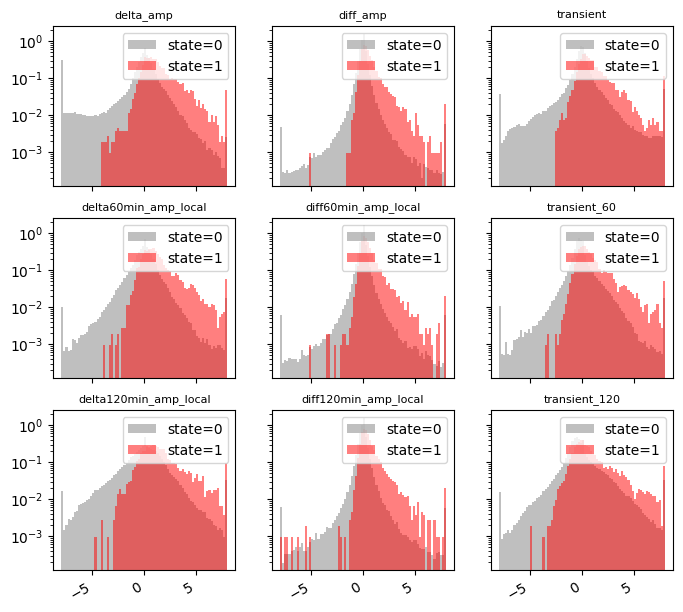

In [45]:
%matplotlib inline
df_diurno.columns
features_ = ['delta_amp', 'diff_amp', 'transient', 'delta60min_amp_local', 'diff60min_amp_local', 'transient_60',
        'delta120min_amp_local', 'diff120min_amp_local', 'transient_120']
print(len(features_))
fig, axs = plt.subplots(3,3, sharey=True,figsize=(8,8))#sharex=True)
bins = np.linspace(-8, 8, 81)
for r, rax in enumerate(axs):
    for c, ax in enumerate(rax):
        ii = 3*r+c
        f = features_[ii]
        print("Feature:", f)
        for s, color in [(0, "gray"), (1, "red")]:
            mask = df_diurno["state"] == s
            n, b, p = ax.hist(df_diurno.loc[mask, f].clip(-8, 8),
                    bins=bins, alpha=0.5, density=True,
                    color=color, label=f"state={s}")
            ax.set_title(f"{f}", fontsize=8)
            print(f"Estado: s={s}")
            print(f"values of bins: {n}")
            print(f"bins: {b}")
        ax.set_yscale("log")
        #n, b, p = ax.hist(df_diurno[f],bins=50, color="forestgreen", edgecolor="k", label=f)
        
        print("-"*10, "\n")
        ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.show()

In [31]:
_states = df["state"].values

onset_duration = df.index[np.pad(np.diff(_states),(1, 0))==-1] - df.index[np.pad(np.diff(_states),(1, 0))==1]
onset_duration = onset_duration.astype('timedelta64[s]')/np.timedelta64(60,"s" )
onset_duration
# for l in zip(df_diurno.index[np.pad(np.diff(_states),(1, 0))==1] , df_diurno.index[np.pad(np.diff(_states),(1, 0))==-1]):
#     print(l)

Index([16.0, 13.0,  6.0, 13.0, 17.0, 20.0,  7.0,  8.0,  8.0, 18.0,
       ...
       14.0, 21.0, 10.0,  7.0,  8.0,  6.0, 12.0, 10.0,  8.0, 12.0],
      dtype='float64', length=373)

In [45]:
_ii = np.argmax(onset_duration)
_ti = df_diurno.index[np.pad(np.diff(_states),(1, 0))==1]
_ti[_ii]

Timestamp('2025-04-04 23:05:00')

In [66]:
%matplotlib inline

Text(0.5, 1.0, 'Onset duration (in minutes)')

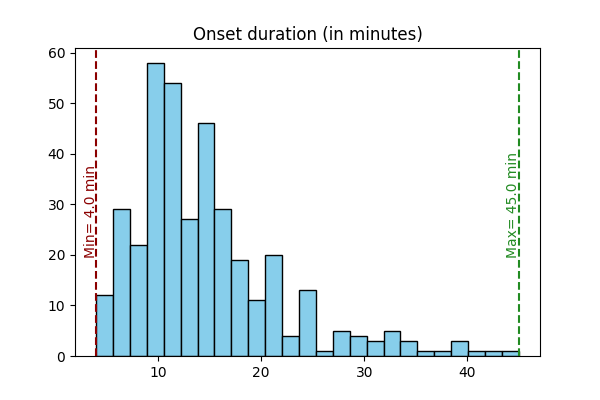

In [157]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration, bins=25, edgecolor="k", facecolor="skyblue")
min_duration = min(onset_duration) 
max_duration = max(onset_duration) 
plt.axvline(x=min(onset_duration), ls="--", color="darkred")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="darkred")
plt.axvline(x=max(onset_duration), ls="--", color="forestgreen")
plt.text(max_duration-1.2, 20, f"Max= {max_duration} min", rotation="vertical", color="forestgreen")
plt.title("Onset duration (in minutes)")

<Axes: ylabel='Frequency'>

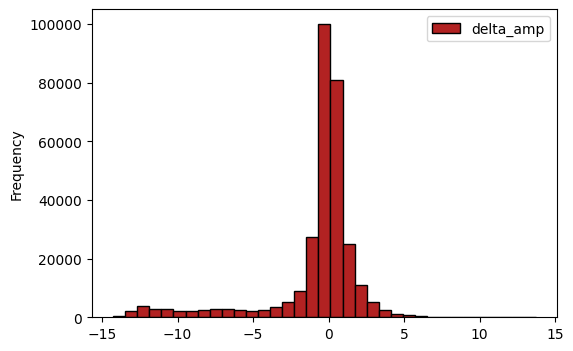

In [33]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")


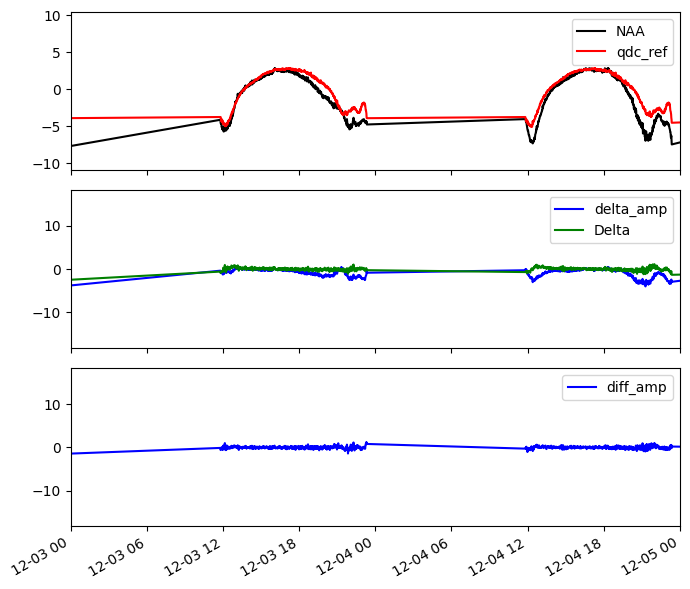

In [34]:

dl1, dl2 = dt.datetime(2025, 12, 3), dt.datetime(2025, 12, 5)

# 1. Creación de subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 6
                                                   ), sharex=True)

# 2. Graficación de señales
df_diurno[["NAA", "qdc_ref"]].plot(color=["black", "red"], ax=ax1)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax2)
df_diurno[["Delta"]].plot(color=["green"], ax=ax2)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax3)

# 3. Mapeo de colores para cada estado {1, 2}
colores_estado = {
    1: ('red', 0.35, 'Onset (s=1)'),
    2: ('orange', 0.35, 'Decay (s=2)')
}

# 4. Aplicación de las bandas de color en todos los subplots
axes = [ax1, ax2, ax3]

for ax in axes:
    for estado, (color, alpha, label) in colores_estado.items():
        ax.fill_between(
            df_diurno.index, 0, 1,
            where=(df_diurno['state'] == estado),
            color=color, alpha=alpha,
            transform=ax.get_xaxis_transform(),
            step='mid'
        )

# Configuración final
ax1.set_xlim(dl1, dl2)
plt.tight_layout()
plt.show()

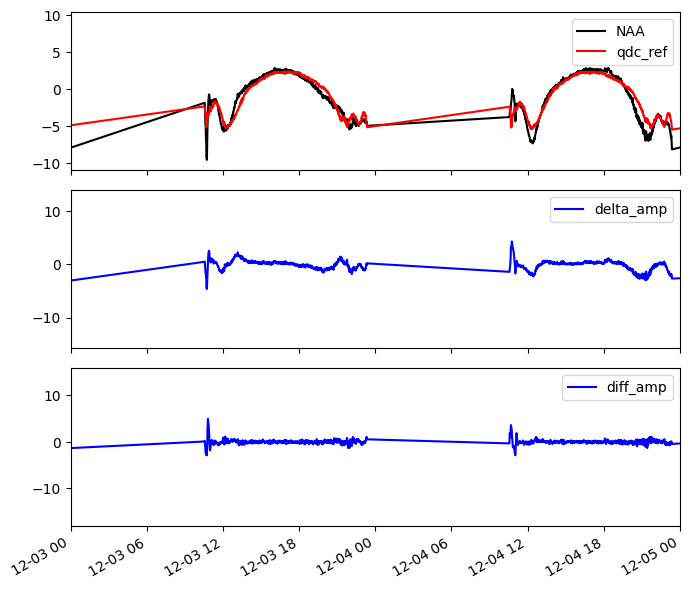

Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -693368.23981614             +nan
         2 -537680.91954947 +155687.32026666
         3 -372166.59517476 +165514.32437471
         4 -325114.64434873  +47051.95082603
         5 -322630.39120189   +2484.25314684
         6 -322236.53826575    +393.85293614
         7 -322146.32047852     +90.21778723
         8 -322122.60132590     +23.71915263
         9 -322115.52391102      +7.07741488
        10 -322113.32929040      +2.19462062
        11 -322112.65312884      +0.67616156
        12 -322112.44766841      +0.20546042
        13 -322112.38587919      +0.06178922
        14 -322112.36740822      +0.01847097


[OK] model Converged!

Transmat
model transmat A:
 [[0.97989283 0.02010717]
 [0.00531139 0.99468861]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted events:	 234

 ----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.40      0.30      0.34        91

    accuracy                           0.20       132
   macro avg       0.20      0.15      0.17       132
weighted avg       0.27      0.20      0.23       132

Nueva Matriz de Confusión:
[[ 0 41]
 [64 27]]
Endr of the training & validation


        15 -322112.36190587      +0.00550235


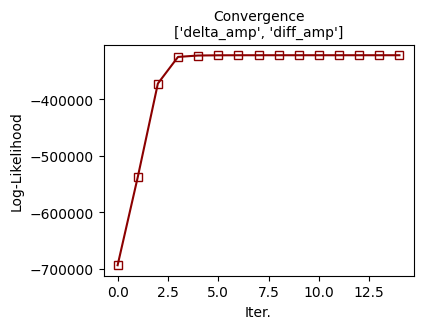

In [35]:
features = ["delta_amp", "diff_amp"]
print("Features used:", features)
X = df_diurno[features].values
y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
t = df_diurno.index

split_idx = int(0.8 * len(X))
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # ONLY transform on test

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# # Cortamos al 80% del tiempo.
# split_idx = int(len(X_scaled) * 0.8)

# X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = t[:split_idx], t[split_idx:]
X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# Usamos los datos de TRAIN para definir qué es cada estado.

def calculate_mean_and_cov(features, labels):
    unique_labels = np.unique(labels)
    n_states = len(unique_labels)
    n_features = features.shape[1]
    
    means = np.zeros((n_states, n_features))
    covars = np.zeros((n_states, n_features, n_features))
    
    for i, state in enumerate(unique_labels):
        state_data = features[labels == state]
        means[i] = np.mean(state_data, axis=0)
        cov = np.cov(state_data.T)
        min_covar = 1e-4  # Valor pequeño para darle "volumen" a la gaussiana
        cov = cov + np.eye(n_features) * min_covar
        
        cov = (cov + cov.T) / 2
        covars[i] = cov
        
    return means, covars


def calculate_startprob(labels):

    n_states = len(np.unique(labels))
    startprob = np.zeros(n_states)

    initial_state = int(labels[0])
    startprob[initial_state] = 1.0

    return startprob
    
def calculate_transmat(labels):

    n_states = len(np.unique(labels))
    transmat = np.zeros((n_states, n_states))

    # 1. Contar todas las transiciones en la secuencia
    for i in range(len(labels) - 1):
        from_state = int(labels[i])
        to_state = int(labels[i+1])
        transmat[from_state, to_state] += 1

    row_sums = transmat.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        transmat = np.where(row_sums > 0, transmat / row_sums, 0)
    return transmat

# 
startprob = calculate_startprob(y_train)
transmat = calculate_transmat(y_train)
means, covars = calculate_mean_and_cov(X_train, y_train)
print("Transition Matrix A:\n",transmat)

# init the model
model = hmm.GaussianHMM(
    n_components=2, 
    covariance_type="full", 
    # init_params="smc", # 
    init_params="",
    min_covar=1e-3, 
    n_iter=50,          # Le damos iteraciones para converger
    verbose=True
)

model.startprob_ = startprob
model.transmat_ = transmat
model.means_ = means
model.covars_ = covars

print("\nAfinando parámetros con algoritmo EM...")
model.fit(X_train)

if model.monitor_.converged:
# print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
    print("[OK] model Converged!")
    fig = plt.figure(figsize=(4,3))
    plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
    #model.monitor_.n_iter
    plt.xlabel("Iter.")
    plt.ylabel("Log-Likelihood")
    plt.title(f"Convergence\n{features}", fontsize=10)
    
    print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
    print("\ninitial transmat\n",transmat)
    y_pred = model.predict(X_test)
    # processing the predicted states: grab time intervals
    rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
    decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
    rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
    decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
    # validate rise s=1 match - rise_true_intervals
    matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
    print("\n", "--"*50)
    print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Nueva Matriz de Confusión:")
    print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Endr of the training & validation")
else:
    print("[!!] model NOT Converged!\n-> End of the training.")


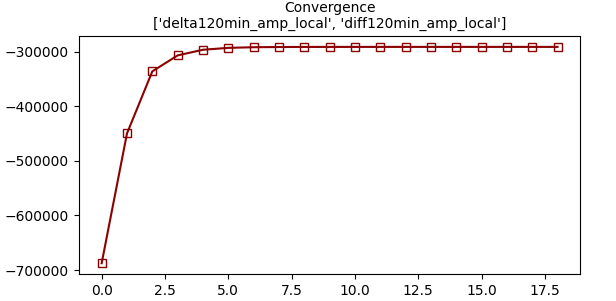

In [149]:
# fig = plt.figure()
# ax = plt.subplot(211)
# plt.plot(model.means_, label="means") 
# plt.legend()
# ax = plt.subplot(212)
# ax.plot(model.covars_, label="covars")
# ax.legend()

In [36]:
#prediction
y_pred = model.predict(X_test)

In [53]:
import importlib
importlib.reload(mu)

<module 'modelutils' from '/home/diace/notebooks/aldo/flare/modelutils.py'>

In [162]:
def filter_smooth_ypred(y_pred, t_pred, s, lower, upper):
    '''
    y_pred : predicted sequence of states array
    y_pred : time  array for the y_test array (equivalently for the y_pred)
    s      : target state
    lower/upper  : minmum/maximum duraton in minutes
    ---
    Returns: filtered y_pred º
    '''       
    _start, _end = state_regime_range(y_pred, t_pred, s)
    _td = (_end - _start)/np.timedelta64(1, "m") # time delta
    return y_pred[(lower <= _td) & (_td >= upper)]

def state_regime_range(s_arr, t_arr, s=1):
    '''
    s_arr  : sequence of states array
    t_arr  : time array
    s      : target state value
    ---
    Returns: t_start, t_end
    '''
    s_arr[-1] = 0 if s_arr[-1] == s else s_arr[-1] 
    mask_s_arr = s_arr==s
    diff_y = np.diff((mask_s_arr==s)/1) if  (s_arr[-1]!=s) else np.diff(np.pad(mask_s_arr, (0, 1), 'constant', constant_values=(0)))
    
    ti_end   = t_arr[np.pad(diff_y, (1, 0))==-1] # /1 because of the boolen in == and the following math operatins
    ti_start = t_arr[np.pad(diff_y, (1, 0))==1]
    # if  len(ti_start)-len(ti_end) == 1:
        
        
    # print(len(ti_end), len(ti_start))
    # s_duration_pred = ti_end - ti_start
    # return s_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )
    # for l in zip(ti_end, ti_start):
        # print(l, (l[0]-l[1])/np.timedelta64(60,"s"))
    return ti_start, ti_end
    

In [160]:
# np.pad([2,1,3,4,5,3,2], (0, 1), 'constant', constant_values=(0))
# a = np.diff(_y_pred) #np.pad(_y_pred, (0, 1), 'constant', constant_values=(0))
s_arr = _y_pred
s = 1
print(s_arr[-1], s)
diff_y = np.diff((s_arr==s)/1) if  (s_arr[-1]!=s) else np.diff(np.pad(s_arr, (0, 1), 'constant', constant_values=(0)))
print(diff_y)

0 1
[ 1.  0.  0. ...  0.  0. -1.]


In [166]:
# filter_smooth_ypred(_y_pred,t_test, s=1,lower=3, upper=60 )
_start, _end = state_regime_range(_y_pred, t_test, s=1)
_td = (_end - _start)/np.timedelta64(1, "m") # time delta

In [174]:
_end[1] - _start[1], (4 <=(_end[1] - _start[1])/np.timedelta64(1,"m") <= 60)

(Timedelta('0 days 08:47:00'), False)

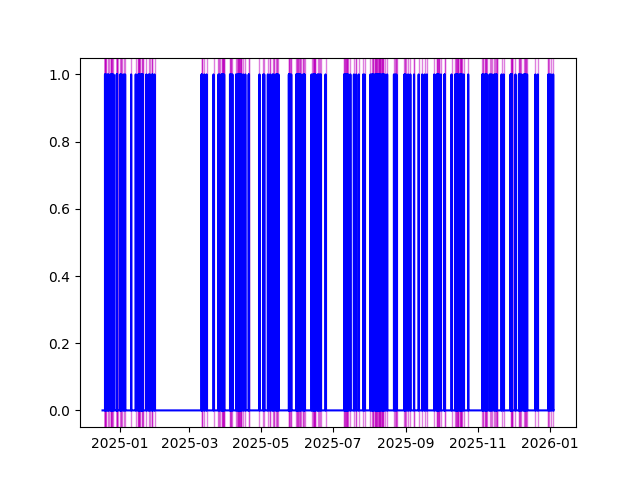

In [106]:
# filter_smooth_ypred(_y_pred, )
%matplotlib widget
t1, t2 = state_regime_duration(y_train, t_train, 1 )
fig = plt.figure()
plt.step(t_train, y_train, color="b")
for ti, tf in zip(t1,t2):
    plt.axvspan(ti,tf, -0.1, 1.1, color="m", alpha=0.5)
plt.show()

In [120]:
print(sum(np.diff(_y_pred)==1), sum(np.diff(_y_pred)==-1))
print(_y_pred[0], _y_pred[-1])


257 256
0 1


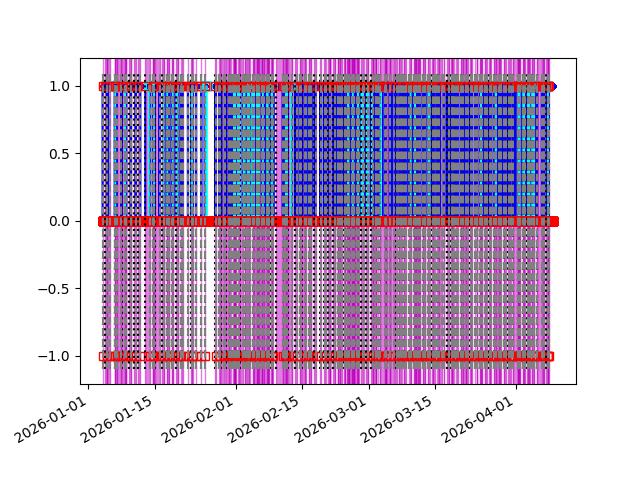

In [123]:
# filter_smooth_ypred(_y_pred, )
%matplotlib widget
t1, t2 = state_regime_duration(_y_pred, t_test, 1 )
fig = plt.figure()
plt.step(t_test, _y_pred, color="b", marker=".", "_y_test")
plt.step(t_test, y_test, color="cyan", lw=1, ls="-", marker="s", markerfacecolor="none", label="y_test")
plt.plot(t_test[1:], np.diff(_y_pred), color="r",lw=0, marker="s",markerfacecolor="none", label="diff(_y_pred)")
for ti, tf in zip(t1,t2):
    plt.axvspan(ti,tf, -0.1, 1.1, color="m", alpha=0.5)
plt.vlines(t1,-1.1, 1.1, lw=1.5, color="k", ls=":")
plt.vlines(t2,-1.1, 1.1, lw=1.5, color="gray", ls="--")
fig.autofmt_xdate()
plt.show()

In [ ]:
plt.figure()
plt.plot(df["NAA"].loc[dt.datetime()])

In [117]:
plt.close("all")

In [130]:
print(len(_y_pred), len(t_test))
state_regime_range(_y_pred, t_test,1)
# t_test

68252 68252


(DatetimeIndex(['2026-01-03 23:06:00', '2026-01-04 12:06:00',
                '2026-01-04 21:56:00', '2026-01-04 23:33:00',
                '2026-01-06 12:19:00', '2026-01-06 15:49:00',
                '2026-01-06 15:54:00', '2026-01-06 23:33:00',
                '2026-01-07 22:03:00', '2026-01-07 23:32:00',
                ...
                '2026-04-05 11:12:00', '2026-04-05 12:50:00',
                '2026-04-06 19:24:00', '2026-04-06 19:46:00',
                '2026-04-06 21:46:00', '2026-04-07 11:31:00',
                '2026-04-07 18:53:00', '2026-04-07 19:46:00',
                '2026-04-07 19:52:00', '2026-04-07 22:55:00'],
               dtype='datetime64[us]', length=257, freq=None),
 DatetimeIndex(['2026-01-03 23:18:00', '2026-01-04 20:53:00',
                '2026-01-04 22:50:00', '2026-01-05 12:06:00',
                '2026-01-06 15:48:00', '2026-01-06 15:53:00',
                '2026-01-06 21:40:00', '2026-01-07 21:36:00',
                '2026-01-07 22:23:00', '2026-01-

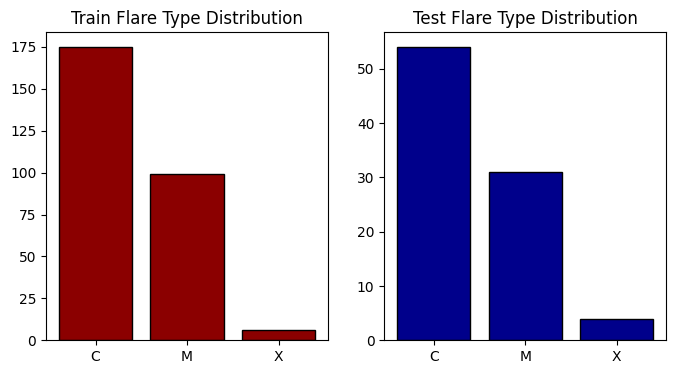

In [68]:
train_flares_dist = {"C":0, "M":0, "X":0}
rise_true_intervals_train = mu.find_state_intervals(t_train, y_train, target=1)
for (t0, t1) in rise_true_intervals_train:
    cls = mu.classify_flare(mu.peak_flux_in(df, t0, t1))
    #print(f"  {t0}  {cls}  peak={mu.peak_flux_in(df, t0, t1):.2e}")
    if cls in train_flares_dist.keys():
        train_flares_dist[cls] += 1

flares_dist = {"C":0, "M":0, "X":0}
for (t0, t1) in rise_true_intervals:
    cls = mu.classify_flare(mu.peak_flux_in(df, t0, t1))
    #print(f"  {t0}  {cls}  peak={mu.peak_flux_in(df, t0, t1):.2e}")
    if cls in flares_dist.keys():
        flares_dist[cls] += 1



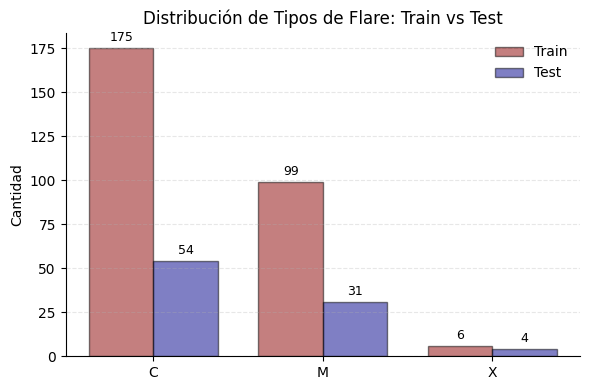

In [84]:
categories = sorted(set(train_flares_dist.keys()) | set(flares_dist.keys()))

train_vals = [train_flares_dist.get(c, 0) for c in categories]
test_vals = [flares_dist.get(c, 0) for c in categories]

x = np.arange(len(categories))
width = 0.38

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width/2, train_vals, width, label="Train",
                color="darkred", edgecolor="k", alpha=0.5)
bars2 = ax.bar(x + width/2, test_vals, width, label="Test",
                color="darkblue", edgecolor="k", alpha=0.5)

# Etiquetas con el valor encima de cada barra
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de Tipos de Flare: Train vs Test")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### freeze the transmat


In [85]:
df_diurno.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'NAA-filt', 'NAA_dB_bgrm', 'Delta',
       'time', 'date', 'qdc_ref', 'delta_amp', 'diff_amp', 'slope_5m',
       'slope_10m', 'transient', 'rv_5m', 'bp_energy', 'bg_local_60min',
       'delta60min_amp_local', 'diff60min_amp_local', 'transient_60',
       'bg_local_120min', 'delta120min_amp_local', 'diff120min_amp_local',
       'transient_120', 'rise_score', 'cos_theta'],
      dtype='str')

In [87]:
%%capture captured_outtext --no-stderr
params = "mc"
init_params = ""
comments= f'''
se ha implementado un filtro para eliminar predicciones de muy corta duracion (por debajo del minimo observado en los datos=4min)
seha implementado el trasient tmado desde delta120min_amp_local en vez de usar el delta_amp usando qtc

params={params}
init_params={init_params}
'''
print("comments:\n", comments)
print("---")

listoffeatures = [
    ["Delta"],
    ["delta_amp", "diff_amp"], 
    ["delta60min_amp_local", "diff60min_amp_local"], 
    ["delta60min_amp_local", "diff60min_amp_local", "cos_theta"],
    ["delta120min_amp_local", "diff120min_amp_local"],
    ["delta120min_amp_local", "diff120min_amp_local", "cos_theta"],
    [ "transient", "cos_theta"],
    ["transient_60", "cos_theta"],
    ["transient_120", "cos_theta"],
    ["transient", "delta120min_amp_local"],
    ["bp_energy"],
    ["bp_energy", "cos_theta"],
]

trials = {}

n_trial = 0
for k, lf in enumerate(listoffeatures):
    print(f"\n==== Trial {k} ==============" )
    features = lf
    trials[k] = {"features": features}
    print("Features used:", features)
    X = df_diurno[features].values
    y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
    t = df_diurno.index
    
    split_idx = int(0.8 * len(X))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
    X_test  = scaler.transform(X_test_raw)        # ONLY transform on test
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # # Cortamos al 80% del tiempo.
    # split_idx = int(len(X_scaled) * 0.8)
    
    # X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    t_train, t_test = t[:split_idx], t[split_idx:]
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 
    startprob = mu.calculate_startprob(y_train)
    transmat = mu.calculate_transmat(y_train)
    means, covars = mu.calculate_mean_and_cov(X_train, y_train)
    print("Transition Matrix A:\n",transmat)
    
    # init the model
    model = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        init_params=init_params,
        params=params,          # <-- freeze startprob AND transmat
        min_covar=1e-3,
        n_iter=50,
        verbose=True,
    )
    model.startprob_ = startprob
    model.transmat_ = transmat
    model.means_    = means
    model.covars_   = covars
    
    print("\nAfinando parámetros con algoritmo EM...")
    model.fit(X_train)
    
    if model.monitor_.converged:
    # print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
        print("[OK] model Converged!")
        fig = plt.figure(figsize=(4,3))
        plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
        #model.monitor_.n_iter
        plt.xlabel("Iter.")
        plt.ylabel("Log-Likelihood")
        plt.title(f"Convergence\n{features}", fontsize=10)
        
        print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
        print("\ninitial transmat\n",transmat)
        y_pred = model.predict(X_test)
        # y_pred  = filter_smooth_ypred(_y_pred, t_test, 1 ,4,120)
        # processing the predicted states: grab time intervals
        rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
        decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
        rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
        decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
        # validate rise s=1 match - rise_true_intervals
        matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
        print("\n", "-"*50)
        print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Nueva Matriz de Confusión:")
        
        print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))

        # Flares
        print()
        for cls in ["C", "M", "X"]:
            m = mu.event_metrics_by_threshold(matchdf_smooth, rise_true_intervals, df,
                                           min_class=cls)
            print(f"≥{cls}:  P={m['P']:.3f}  R={m['R']:.3f}  F1={m['F1']:.3f}  "
                  f"(TP={m['TP']}, FP={m['FP']}, FN={m['FN']})")
        mplus_fns = []
        for _, row in matchdf_smooth[(matchdf_smooth["true"]==1) & (matchdf_smooth["pred"]==0)].iterrows():
            t0, t1 = row["t_true_1"], row["t_true_2"]
            p = mu.peak_flux_in(df, t0, t1)
            if mu.classify_flare(p) in ("M", "X"):
                ctheta = df.loc[t0, "cos_theta"] if t0 in df.index else np.nan
                mplus_fns.append((t0, mu.classify_flare(p), p, ctheta))


        df_fn = pd.DataFrame(mplus_fns, columns=["t0","cls","flux","cos_theta"])
        print(df_fn.to_string())
        print("\ncos_theta mediana:", df_fn["cos_theta"].median())        
    else:
        print("[!!] model NOT Converged!\n-> End of the training.")

print("\n","="*50, "\nEnd of the training & validation")


         1 -352605.75371774             +nan
         2 -225168.64452942 +127437.10918832
         3 -214964.65081532  +10203.99371411
         4 -212700.73953743   +2263.91127789
         5 -211973.36717054    +727.37236689
         6 -211730.76851824    +242.59865229
         7 -211640.29265471     +90.47586354
         8 -211604.23340255     +36.05925215
         9 -211589.75641069     +14.47699187
        10 -211583.97951769      +5.77689300
        11 -211581.68738702      +2.29213067
        12 -211580.78131400      +0.90607302
        13 -211580.42395118      +0.35736283
        14 -211580.28319059      +0.14076058
        15 -211580.22778867      +0.05540192
        16 -211580.20599202      +0.02179665
        17 -211580.19741814      +0.00857388
         1 -693368.23981614             +nan
         2 -550709.85092557 +142658.38889057
         3 -385858.62038515 +164851.23054042
         4 -337815.11480232  +48043.50558283
         5 -335437.71194672   +2377.40285561
         6

In [88]:
aout = captured_outtext.stdout
print(aout)

comments:
 
se ha implementado un filtro para eliminar predicciones de muy corta duracion (por debajo del minimo observado en los datos=4min)
seha implementado el trasient tmado desde delta120min_amp_local en vez de usar el delta_amp usando qtc

params=mc
init_params=

---

==== Trial 0 ==============
Features used: ['Delta']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...
[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted (raw) events:	 331

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       177
           1       0.22      0.56      0.32        90

    accuracy                           0.19       267
   macro avg       0.11  

In [81]:
with open(f"train_params_{params}-initparams_{init_params}_alignright_flareclass.txt", "w") as f:
    f.write(captured_outtext.stdout)

In [96]:
onset_duration_pred = t_test[np.pad(np.diff(y_pred),(1, 0))==-1] - t_test[np.pad(np.diff(y_pred),(1, 0))==1]
onset_duration_pred = onset_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )
sum(onset_duration_pred<4)

np.int64(9)

In [ ]:
t_arr = t_test
s_arr = y_pre
s_duration_pred = t_arr[np.pad(np.diff(s_arr==s),(1, 0))==-1] - t_arr[np.pad(np.diff(s_arr==s),(1, 0))==1]
dd = s_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )


In [63]:
_y_pred, y_pred

(array([0, 1, 1, ..., 0, 0, 0], shape=(68252,)), array([], dtype=int64))

In [105]:
ts  = t_test[np.pad(np.diff(y_pred),(1, 0))==1]
print("----1\n", ts[onset_duration_pred==1])
print("----2\n", ts[onset_duration_pred==2])
print("----3\n", ts[onset_duration_pred==3])

----1
 DatetimeIndex(['2026-01-06 15:48:00', '2026-02-17 23:05:00',
               '2026-02-18 18:47:00', '2026-02-20 22:25:00',
               '2026-03-04 14:39:00', '2026-04-07 19:45:00'],
              dtype='datetime64[ns]', freq=None)
----2
 DatetimeIndex(['2026-03-16 18:39:00'], dtype='datetime64[ns]', freq=None)
----3
 DatetimeIndex(['2026-03-28 15:49:00', '2026-04-06 21:38:00'], dtype='datetime64[ns]', freq=None)


Text(0.5, 1.0, 'Onset duration (in minutes)')

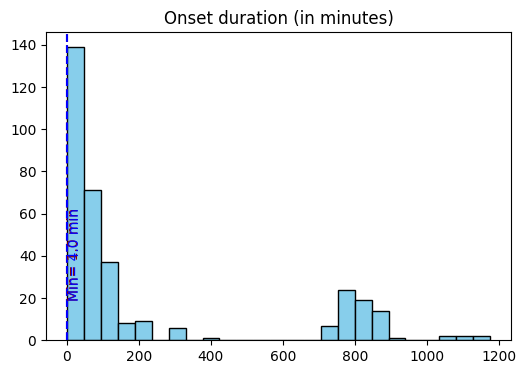

In [100]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration_pred, bins=25, edgecolor="k", facecolor="skyblue")
min_duration_pred = min(onset_duration_pred) 
plt.axvline(x=min(onset_duration_pred), ls="--", color="darkred")
plt.text(min_duration_pred-1.2, 20, f"Min= {min_duration_pred} min", rotation="vertical", color="darkred")

# min duration true
plt.axvline(x=min(onset_duration), ls="--", color="blue")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="blue")
plt.title("Onset duration (in minutes)")
# plt.xscale("log")#

In [58]:
dl = [
    dt.datetime(2026, 1,1),
    dt.datetime(2026, 4, 10)
    ]

fig, axs = plt.subplots(2,1,sharex=True)
ax0 = axs[0]

#ax0.plot(t_test, X_test[:,0], color="gray", lw=1,label="Signal")
#ax0.plot(t_test, X_test[:,1], color="blue", lw=1, label="Diff. Signal")
ax0.plot(df["NAA"].loc[dl[0]:dl[1]], color="black", lw=1, label="Signal raw")
ax0.plot(df_diurno["delta_amp"].loc[dl[0]:dl[1]], color="navy", lw=1, label="Delta-amp")
ax1 = ax0.twinx()
testmask = (dl[0]<t_test) & (t_test<dl[1])
ax1.plot(t_test[testmask], y_test[testmask], color="red", ls="--", lw=1.5, label="True state")
for t1,t2 in zip(matchdf_smooth["t_pred_1"], matchdf_smooth["t_pred_2"]):
    if not pd.isna(t1):
        ax1.axvspan(t1,t2, color="yellowgreen",alpha=0.6, label="Predicted event")
#plt.legend(l,"Predicted event")
ax0.set_ylabel("Amp. (dB)")

ax0.legend()
ax1.set_ylabel("State")
ax2 = axs[1]
ax2.plot(df['GOES18'].loc[dl[0]:dl[1]], color="purple",label="X rays GOES")
ax2.set_ylabel("Flux (W/m²)")
ax2.set_yscale("log")
ax2.set_xlabel("Time UT")
fig.autofmt_xdate()

In [57]:
plt.close()

In [60]:
print("true events", sum(np.diff(y_test==1) > 0))
print("pred events", sum(np.diff(y_pred==1) > 0))

true events 180
pred events 480


In [48]:
matchdf_smooth

,t_true_1,t_true_2,t_pred_1,t_pred_2,true,pred
0,NaT,NaT,2026-01-04 13:25:00,2026-01-04 13:28:00,0,1
1,NaT,NaT,2026-01-04 21:40:00,2026-01-04 21:46:00,0,1
2,NaT,NaT,2026-01-04 22:28:00,2026-01-04 22:31:00,0,1
3,NaT,NaT,2026-01-05 23:31:00,2026-01-06 12:07:00,0,1
4,NaT,NaT,2026-01-06 12:50:00,2026-01-06 12:53:00,0,1
...,...,...,...,...,...,...
372,NaT,NaT,2026-04-06 19:39:00,2026-04-06 19:42:00,0,1
373,NaT,NaT,2026-04-06 19:44:00,2026-04-06 19:47:00,0,1
374,NaT,NaT,2026-04-06 21:38:00,2026-04-06 21:58:00,0,1
375,NaT,NaT,2026-04-06 22:51:00,2026-04-06 22:58:00,0,1


In [57]:
plt.figure()
plt.plot(t_train, X_train)
plt.legend()

/tmp/ipykernel_8846/1644147617.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [111]:
%matplotlib qt
plt.figure()
ax = plt.subplot()
ax.plot(t_test, df_diurno.loc[t_test, "NAA"], color="black")
ax2 = ax.twinx()
ax2.plot(t_test,y_test, color="forestgreen", alpha=0.75)
ax2.plot(t_test,y_pred, color="red", alpha=0.7)

plt.show()

## Gaussian Mixture


In [186]:
means, covars, weights = mu.gmm_init_from_labels(X_train, y_train)

comments:
 
GMM-HMM
se ha implementado un filtro para eliminar predicciones de muy corta duracion (por debajo del minimo observado en los datos=4min)
seha implementado el trasient tmado desde delta120min_amp_local en vez de usar el delta_amp usando qtc

params      = mc
init_params =  
NMIX        = 2

---

==== Trial 0 ==============
Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -717174.23647510             +nan
         2 -656276.58236905  +60897.65410604
         3 -604460.16480688  +51816.41756217
         4 -481704.03436260 +122756.13044428
         5 -379665.25245904 +102038.78190356
         6 -322466.34361339  +57198.90884565
         7 -308243.29573053  +14223.04788286
         8 -302389.40279748   +5853.89293304
         9 -299087.93865096   +3301.46414652
        10 -297057.51178732   +2030.42686364
        11 -295772.17491225   +1285.33687507
        12 -294928.06832120    +844.10659106
        13 -294355.04844377    +573.01987743
        14 -293945.90893067    +409.13951310
        15 -293638.59764581    +307.31128485
        16 -293397.59489911    +241.00274670
        17 -293202.46893377    +195.12596534
        18 -293040.84363565    +161.62529812
        19 -292904.82335215    +136.02028350
        20 -292789.05110634    +115.77224581
        21 -292689.48292405     +99.56818229
        22 -292602.94164612     +86.54127794
        23

[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted (raw) events:	 235

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.08      0.09      0.08        90

    accuracy                           0.04       183
   macro avg       0.04      0.04      0.04       183
weighted avg       0.04      0.04      0.04       183

Nueva Matriz de Confusión:
[[ 0 93]
 [82  8]]

==== Trial 1 ==============
Features used: ['delta120min_amp_local', 'diff120min_amp_local']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -708415.06246826             +nan
         2 -565647.75107509 +142767.31139317
         3 -520290.85230694  +45356.89876815
         4 -504524.31887795  +15766.53342899
         5 -496752.93542077   +7771.38345718
         6 -486182.78523827  +10570.15018250
         7 -475579.95721368  +10602.82802459
         8 -469436.39389400   +6143.56331968
         9 -465696.75908606   +3739.63480794
        10 -463006.65580709   +2690.10327897
        11 -460809.87541081   +2196.78039629
        12 -458740.82361465   +2069.05179616
        13 -456077.09984769   +2663.72376696
        14 -452230.24541497   +3846.85443272
        15 -447409.42579960   +4820.81961536
        16 -442459.14784117   +4950.27795843
        17 -438026.49989213   +4432.64794904
        18 -434222.37580570   +3804.12408643
        19 -430841.70800018   +3380.66780553
        20 -427550.15957067   +3291.54842950
        21 -423943.60646514   +3606.55310554
        22 -419554.93553565   +4388.67092949
        23

[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted (raw) events:	 193

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.45      0.11      0.18        90

    accuracy                           0.10       102
   macro avg       0.23      0.06      0.09       102
weighted avg       0.40      0.10      0.16       102

Nueva Matriz de Confusión:
[[ 0 12]
 [80 10]]

==== Trial 2 ==============
Features used: ['delta120min_amp_local', 'diff120min_amp_local', 'transient_120']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


...

         1 -350201.68876193             +nan
         2 -271875.18549744  +78326.50326448
         3 -159086.73755993 +112788.44793752
         4 -119639.26233157  +39447.47522836
         5 -106282.97181821  +13356.29051336
         6 -101686.54939657   +4596.42242164
         7 -100056.22183244   +1630.32756413
         8  -99445.52401771    +610.69781473
         9  -99160.59993712    +284.92408059
        10  -98787.24901989    +373.35091723
        11  -97698.61821577   +1088.63080412
        12  -95658.66100715   +2039.95720862
        13  -93679.25660949   +1979.40439766
        14  -92369.84484370   +1309.41176579
        15  -91610.13565893    +759.70918477
        16  -91174.30166192    +435.83399701
        17  -90924.24929355    +250.05236837
        18  -90772.39091783    +151.85837572
        19  -90665.47472418    +106.91619365
        20  -90567.67622056     +97.79850362
        21  -90450.06466940    +117.61155116
        22  -90285.87627524    +164.18839417
        23

[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted (raw) events:	 277

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.41      0.33      0.37        90

    accuracy                           0.22       134
   macro avg       0.20      0.17      0.18       134
weighted avg       0.27      0.22      0.25       134

Nueva Matriz de Confusión:
[[ 0 44]
 [60 30]]

==== Trial 4 ==============
Features used: ['transient_60']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -322856.23464871             +nan
         2 -214017.78861648 +108838.44603224
         3 -183924.99861199  +30092.79000448
         4 -172558.06045001  +11366.93816198
         5 -167605.97595673   +4952.08449328
         6 -165490.61267679   +2115.36327994
         7 -164639.61706442    +850.99561237
         8 -163858.03350482    +781.58355960
         9 -161501.88846787   +2356.14503695
        10 -159251.96467557   +2249.92379230
        11 -158284.20028966    +967.76438591
        12 -157904.22925830    +379.97103135
        13 -157741.28129534    +162.94796296
        14 -157665.06114198     +76.22015335
        15 -157626.43722653     +38.62391545
        16 -157605.52346738     +20.91375915
        17 -157593.63294018     +11.89052720
        18 -157586.59217454      +7.04076564
        19 -157582.19839367      +4.39378087
        20 -157579.17580299      +3.02259068
        21 -157576.68661635      +2.48918664
        22 -157574.05796291      +2.62865344
        23

[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted (raw) events:	 278

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        66
           1       0.37      0.43      0.40        90

    accuracy                           0.25       156
   macro avg       0.19      0.22      0.20       156
weighted avg       0.21      0.25      0.23       156

Nueva Matriz de Confusión:
[[ 0 66]
 [51 39]]

==== Trial 5 ==============
Features used: ['transient_120']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


KeyboardInterrupt: 

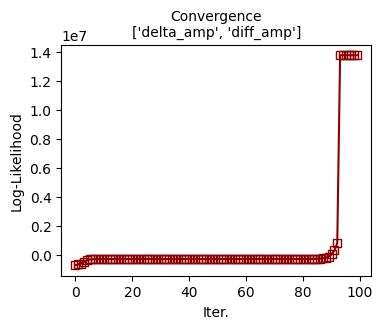

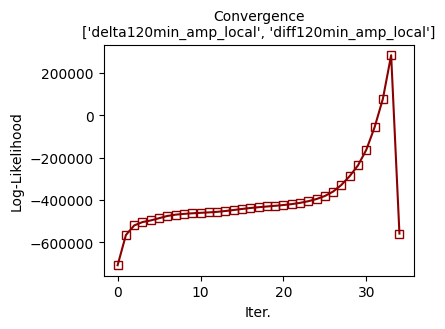

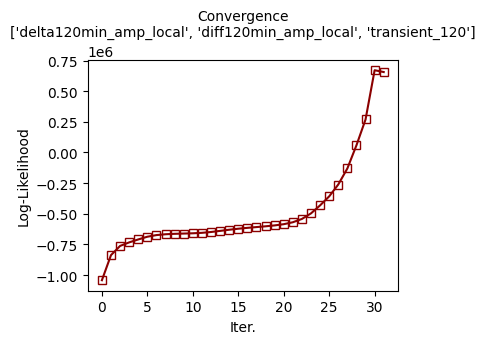

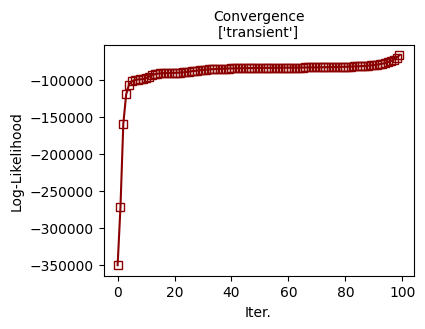

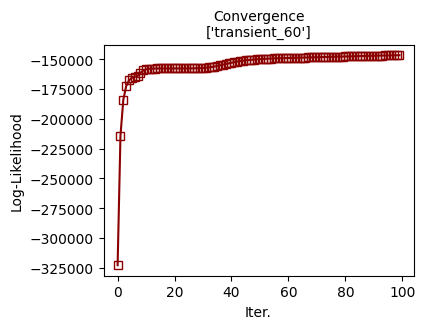

In [49]:
#%%capture captured_outtext --no-stderr
N_MIX       = 2
params      = "mc"
init_params = ""

comments= f'''
GMM-HMM
se ha implementado un filtro para eliminar predicciones de muy corta duracion (por debajo del minimo observado en los datos=4min)
seha implementado el trasient tmado desde delta120min_amp_local en vez de usar el delta_amp usando qtc

params      = {params}
init_params = {init_params} 
NMIX        = {N_MIX}
'''
print("comments:\n", comments)
print("---")

listoffeatures = [
    ["delta_amp", "diff_amp"], 
    ["delta120min_amp_local", "diff120min_amp_local"], 
    ["delta120min_amp_local", "diff120min_amp_local", "transient_120"],
    [ "transient"],
    ["transient_60"],
    ["transient_120"],
    ["transient", "delta120min_amp_local"]
]

n_trial = 0
for k, lf in enumerate(listoffeatures):
    print(f"\n==== Trial {k} ==============" )
    features = lf
    print("Features used:", features)
    X = df_diurno[features].values
    y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
    t = df_diurno.index
    
    split_idx = int(0.8 * len(X))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
    X_test  = scaler.transform(X_test_raw)        # ONLY transform on test
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # # Cortamos al 80% del tiempo.
    # split_idx = int(len(X_scaled) * 0.8)
    
    # X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    t_train, t_test = t[:split_idx], t[split_idx:]
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 
    startprob = mu.calculate_startprob(y_train)
    transmat = mu.calculate_transmat(y_train)
    # means, covars = mu.calculate_mean_and_cov(X_train, y_train) # used for Gaussian
    means, covars, weights = mu.gmm_init_from_labels(X_train, y_train, n_mix=N_MIX, min_covar=1e-3)
    print("Transition Matrix A:\n",transmat)
    
    # init the model
    # model = hmm.GaussianHMM(
    #     n_components=2,
    #     covariance_type="full",
    #     init_params="",
    #     params="mc",          # <-- freeze startprob AND transmat
    #     min_covar=1e-3,
    #     n_iter=50,
    #     verbose=True,
    # )
    model = hmm.GMMHMM(
        n_components=2,
        n_mix=N_MIX,
        covariance_type="diag",
        init_params=init_params,
        params=params,          # <-- freeze startprob AND transmat
        min_covar=1e-3,
        n_iter=100,
        verbose=True,
    )

    model.startprob_ = startprob
    model.transmat_  = transmat
    model.means_     = means
    model.covars_    = covars
    model.weights_   = weights
    
    print("\nAfinando parámetros con algoritmo EM...")
    model.fit(X_train)
    
    if model.monitor_.converged:
    # print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
        print("[OK] model Converged!")
        fig = plt.figure(figsize=(4,3))
        plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
        #model.monitor_.n_iter
        plt.xlabel("Iter.")
        plt.ylabel("Log-Likelihood")
        plt.title(f"Convergence\n{features}", fontsize=10)
        
        print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
        print("\ninitial transmat\n",transmat)
        y_pred = model.predict(X_test)
        # y_pred  = filter_smooth_ypred(_y_pred, t_test, 1 ,4,120)
        # processing the predicted states: grab time intervals
        rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
        decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
        rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
        decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
        # validate rise s=1 match - rise_true_intervals
        matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
        print("\n", "-"*50)
        print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Nueva Matriz de Confusión:")
        print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
        
    else:
        print("[!!] model NOT Converged!\n-> End of the training.")

print("\n","="*50, "\nEnd of the training & validation")


In [ ]:
private